In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

# Data prep

In [2]:
img=cv.imread('./images/grad_pic.jpg')
img.shape

(1024, 768, 3)

In [3]:
def contour_coordinates(contour):
    area = cv.contourArea(contour)
    if area>10:
        M = cv.moments(contour)
        return (int(M['m10']/ M['m00']))

In [4]:
# A simple rectangle contour centered around x=100
fake_contour = np.array([
    [[80, 50]],
    [[120, 50]],
    [[120, 90]],
    [[80, 90]]
], dtype=np.int32)

In [5]:
result = contour_coordinates(fake_contour)
print(f"X-center: {result}")  # Should print something close to 100

X-center: 100


In [6]:
def draw_square(image):
    b = [0,0,0]
    h, w = image.shape[0], image.shape[1]
    if h==w:
        square = image
        return square
    else:
        new_dimensions = (w * 2, h * 2)
        resized_img = cv.resize(img, new_dimensions, interpolation=cv.INTER_CUBIC)
        if h>w:
            padding = (h-w)/2
            dst = cv.copyMakeBorder(resized_img, 0,padding, padding , cv.BORDER_CONSTANT, value = b)
        else:
            dst = cv.copyMakeBorder(resized_img, padding, padding, 0, 0, cv.BORDER_CONSTANT, value=[0, 0, 0])
    return dst

In [7]:
def resize_img(image, dim):
    dim-=4
    squared = img
    r = (float(dim)/squared.shape[1])
    d = (dim, int(squared.shape[0]*r))
    resized = cv.resize(image, d, interpolation=cv.INTER_AREA)
    height, width = resized.shape[0], resized.shape[1]
    if height>width:
        resized = cv.copyMakeBorder(resized, 0, 0, 0,1, cv.BORDER_CONSTANT, value=[0,0,0])
    else:
        resized = cv.copyMakeBorder(resized, 1,0,0, 0, cv.BORDER_CONSTANT, value=[0,0,0])
    resized = cv.copyMakeBorder(resized, 2,2,2,2, cv.BORDER_CONSTANT, value=[0,0,0])
    height, width = resized.shape[0], resized.shape[1]
    return resized

# KNN

In [8]:
or_img = cv.imread('./images/digits (1).png')
or_img.shape

(1000, 2000, 3)

In [9]:
gray_img = cv.cvtColor(or_img, cv.COLOR_BGR2GRAY)
gray_img.shape

(1000, 2000)

In [10]:
resized = cv.pyrDown(gray_img)
resized.shape

(500, 1000)

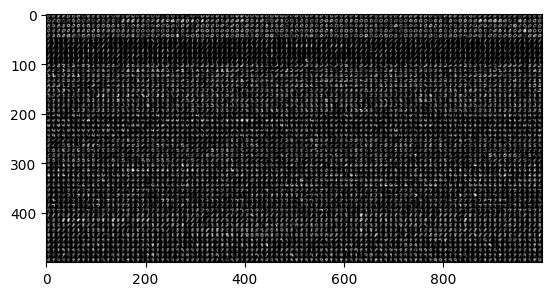

In [11]:
resized_rgb = cv.cvtColor(resized, cv.COLOR_BGR2RGB)
plt.imshow(resized_rgb);

In [12]:
# 50 rows, 100 columns
arr = [np.hsplit(i, 100) for i in np.vsplit(gray_img, 50)]
arr = np.array(arr)
arr.shape

(50, 100, 20, 20)

In [13]:
# train  set
X_train = arr[:, :70].reshape(-1, 400).astype(np.float32)
X_train.shape

(3500, 400)

In [14]:
# test set
X_test = arr[:, 70:100].reshape(-1, 400).astype(np.float32)
X_test.shape

(1500, 400)

In [15]:
# label
labels = [0,1,2,3,4,5,6,7,8,9]
y_train = np.repeat(labels, 350)[:, np.newaxis]

y_test = np.repeat(labels, 150)[:, np.newaxis]
y_train.shape, y_test.shape

((3500, 1), (1500, 1))

In [16]:
# KNN classifier 
knn_classifier = cv.ml.KNearest_create()
knn_classifier.train(X_train, cv.ml.ROW_SAMPLE, y_train)

True

In [17]:
response, result, neighbours, distance = knn_classifier.findNearest(X_test, k = 3)

In [18]:
# accuracy 
np.count_nonzero(result == y_test)/y_test.shape[0] *100

np.float64(93.46666666666667)

# Evaluation

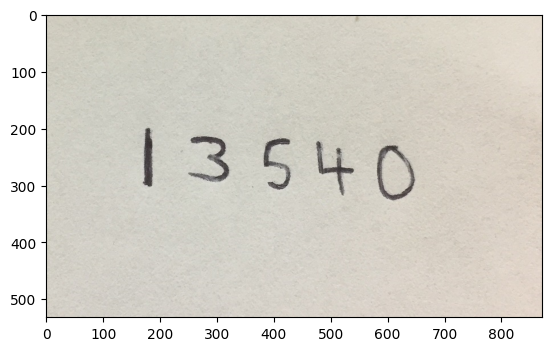

In [19]:
text = cv.imread('./images/text (1).jpg')
text_plt = cv.cvtColor(text, cv.COLOR_BGR2RGB)
plt.imshow(text_plt);

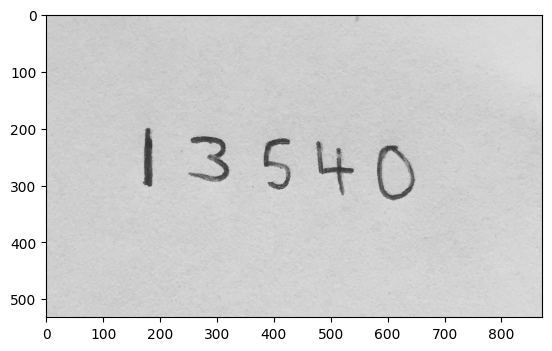

In [20]:
gray_txt = cv.cvtColor(text, cv.COLOR_BGR2GRAY)
plt.imshow(cv.cvtColor(gray_txt, cv.COLOR_BGR2RGB));

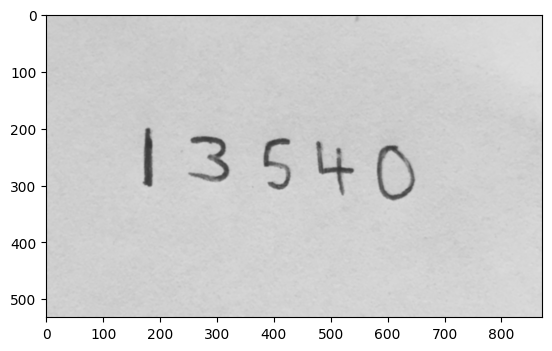

In [21]:
blurred = cv.GaussianBlur(gray_txt, (5,5), 0)
plt.imshow(cv.cvtColor(blurred, cv.COLOR_BGR2RGB));

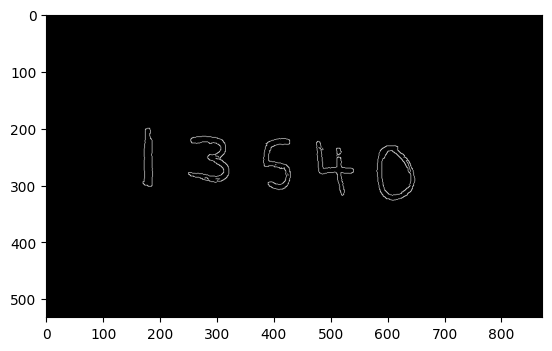

In [22]:
edges = cv.Canny(blurred, 30, 150)
plt.imshow(cv.cvtColor(edges, cv.COLOR_BGR2RGB));

In [23]:
edges_copy = edges.copy()
# 1. Load image and convert to binary/edges (e.g., Canny)
# 2. Use RETR_EXTERNAL or RETR_TREE
# 3. Use CHAIN_APPROX_SIMPLE to save memory
contours,_ = cv.findContours(edges_copy, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
len(contours)

9

In [24]:
contours = sorted(contours, key=lambda c: contour_coordinates(c) or 0, reverse=False)
len(contours)

9

In [25]:
contours[0]

array([[[300, 288]],

       [[299, 289]],

       [[298, 289]],

       [[299, 289]],

       [[300, 288]],

       [[302, 290]],

       [[303, 289]],

       [[305, 289]],

       [[301, 289]]], dtype=int32)

In [26]:
# for contour in contours:
#     (x,y,w,h) = cv.boundingRect(contour)
#     if w>=5 and h>=20:
#         cropped = blurred[y:y+y, x:x+w]
#         cropped = cv.threshold(127, thresh=cv.THRESH_BINARY_INV, maxval=255)
#         squared = draw_square(cropped)
#         resized = resize_img(squared, 20)
#         plt.imshow(cv.cvtColor(resized, cv.COLOR_BGR2RGB))
#         knn_input = resized.reshape((1,400))
#         number = knn_input.astype(np.float32())
#         ret, res, neighbours, distance = knn_classifier.findNearest(result, k=1)
# 		n = str(int(float(res[0])))
# 		display.append(n)
# 		# draw rectangle around individual digit
# 		cv.rectangle(text, (x,y), (x+w, y+h), (0,0,255), 2)
# 		cv.putText(text, n, (x,y+155), cv.FONT_ITALIC, 2, (0,0,130), 2)